In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("disaster_data.csv")
df.head()

,Declaration Number,Declaration Type,Declaration Date,State,County,Disaster Type,Disaster Title,Start Date,End Date,Close Date,Individual Assistance Program,Individuals & Households Program,Public Assistance Program,Hazard Mitigation Program
0,DR-1,Disaster,05/02/1953,GA,NaN,Tornado,Tornado,05/02/1953,05/02/1953,06/01/1954,Yes,No,Yes,Yes
1,DR-2,Disaster,05/15/1953,TX,NaN,Tornado,Tornado and Heavy Rainfall,05/15/1953,05/15/1953,01/01/1958,Yes,No,Yes,Yes
2,DR-3,Disaster,05/29/1953,LA,NaN,Flood,Flood,05/29/1953,05/29/1953,02/01/1960,Yes,No,Yes,Yes
3,DR-4,Disaster,06/02/1953,MI,NaN,Tornado,Tornado,06/02/1953,06/02/1953,02/01/1956,Yes,No,Yes,Yes
4,DR-5,Disaster,06/06/1953,MT,NaN,Flood,Floods,06/06/1953,06/06/1953,12/01/1955,Yes,No,Yes,Yes


In [5]:
df['Declaration Date'] = pd.to_datetime(df['Declaration Date'], errors='coerce')

In [6]:
df['Declaration Date'].isnull().sum()

np.int64(0)

In [7]:
df = df.dropna(subset=['Declaration Date'])

In [8]:
df['year'] = df['Declaration Date'].dt.year
df['month'] = df['Declaration Date'].dt.month
df[['Declaration Date','year','month']].head()

,Declaration Date,year,month
0,1953-05-02,1953,5
1,1953-05-15,1953,5
2,1953-05-29,1953,5
3,1953-06-02,1953,6
4,1953-06-06,1953,6


In [9]:
yearly_trend = df.groupby('year').size()

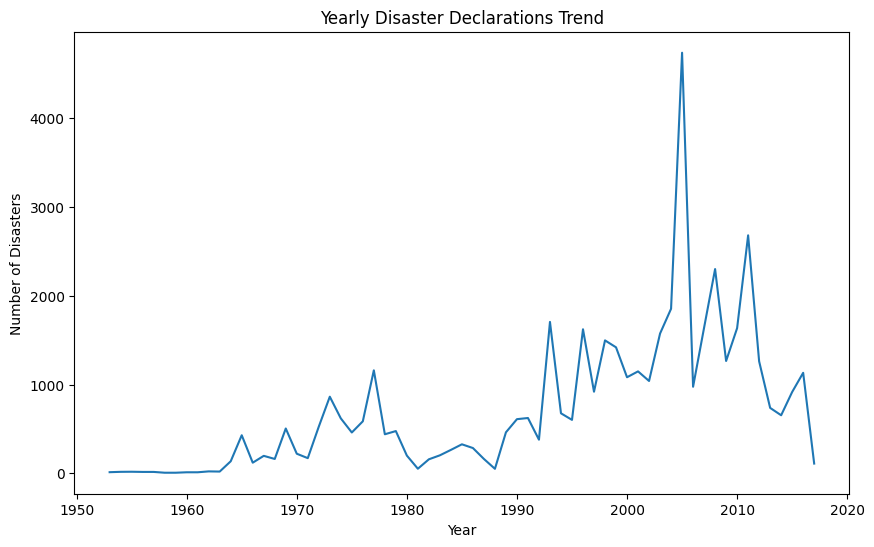

In [10]:
plt.figure(figsize=(10,6))
plt.plot(yearly_trend.index, yearly_trend.values)
plt.title("Yearly Disaster Declarations Trend")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.show()

In [11]:
if not pd.api.types.is_datetime64_any_dtype(df['Declaration Date']):
    df['Declaration Date'] = pd.to_datetime(df['Declaration Date'], errors='coerce')
if 'year' not in df.columns:
    df['year'] = df['Declaration Date'].dt.year
    df['month'] = df['Declaration Date'].dt.month
incident_trend = df.groupby(['year', 'Disaster Type']).size().unstack()

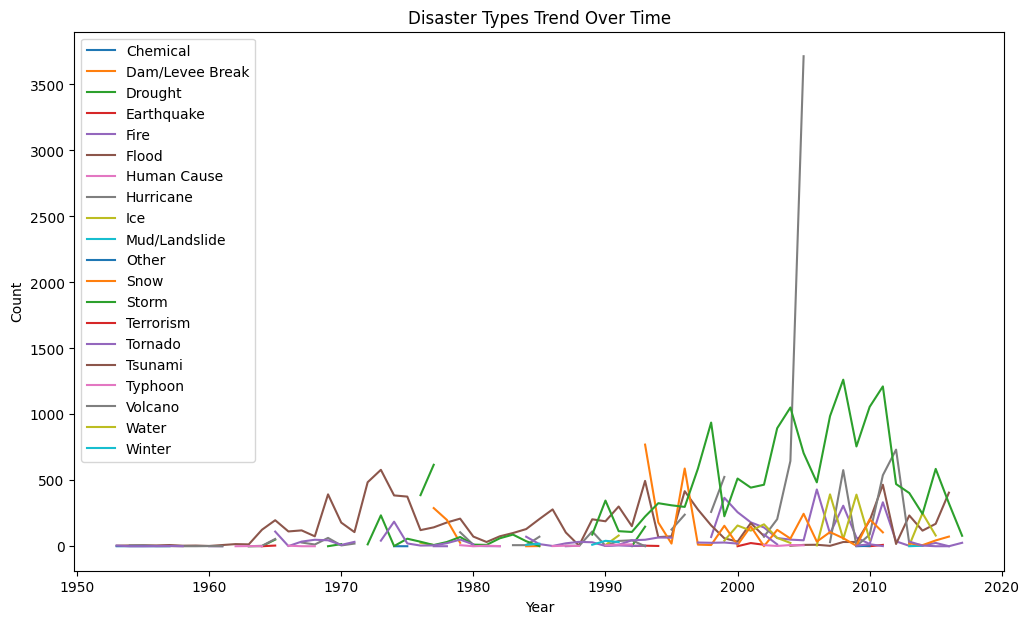

In [12]:
plt.figure(figsize=(12,7))

for column in incident_trend.columns:
    plt.plot(incident_trend.index, incident_trend[column], label=column)

plt.title("Disaster Types Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend()
plt.show()

In [13]:
monthly_trend = df.groupby('month').size()

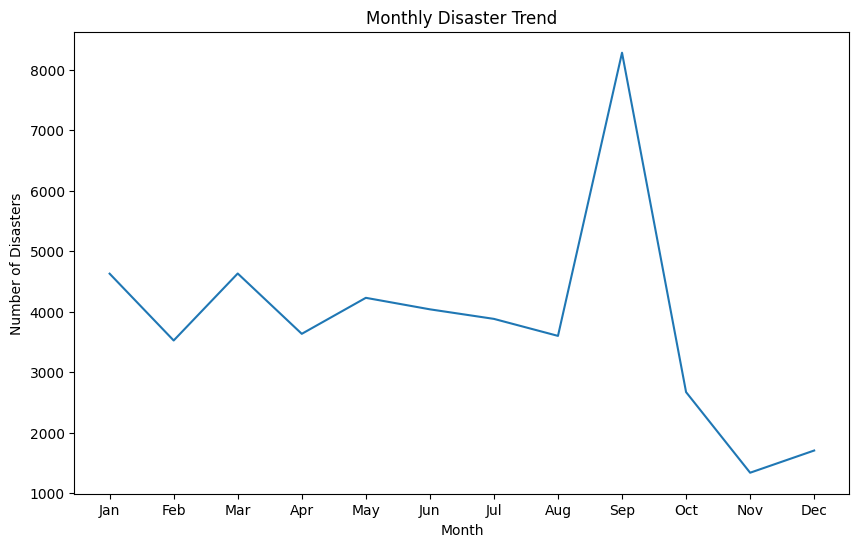

In [14]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
plt.figure(figsize=(10,6))
plt.plot(monthly_trend.index, monthly_trend.values)
plt.title("Monthly Disaster Trend")
plt.xlabel("Month")
plt.ylabel("Number of Disasters")
plt.xticks(range(1,13), months)
plt.show()

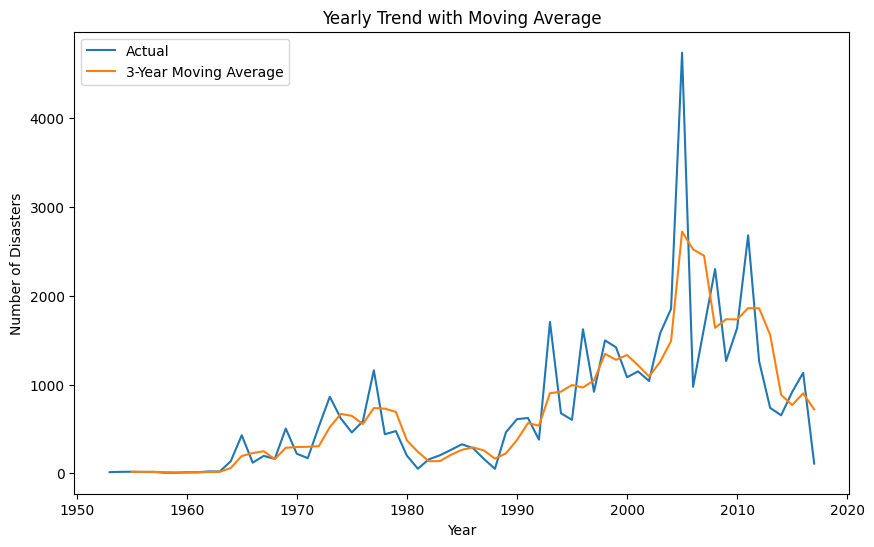

In [15]:
rolling_avg = yearly_trend.rolling(window=3).mean()
plt.figure(figsize=(10,6))
plt.plot(yearly_trend.index, yearly_trend.values, label="Actual")
plt.plot(rolling_avg.index, rolling_avg.values, label="3-Year Moving Average")
plt.title("Yearly Trend with Moving Average")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.legend()
plt.show()

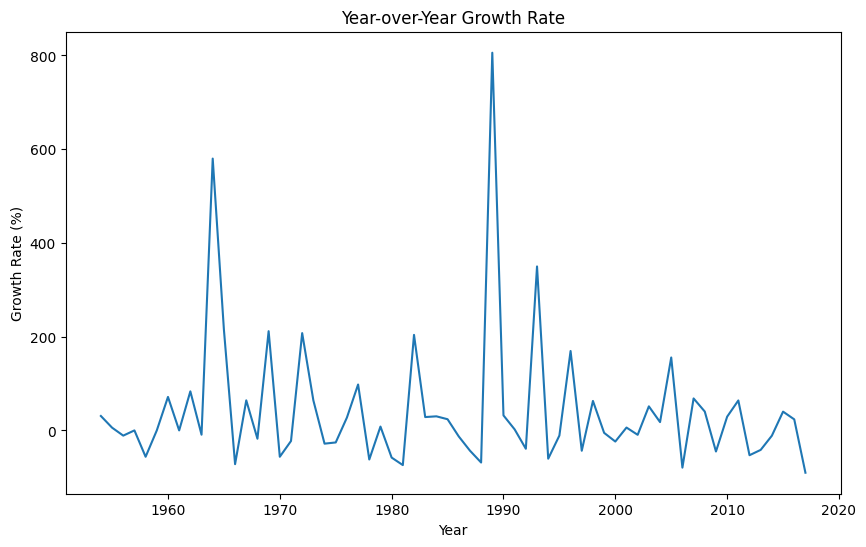

In [ ]:
growth_rate = yearly_trend.pct_change() * 100
plt.figure(figsize=(10,6))
plt.plot(growth_rate.index, growth_rate.values)
plt.title("Year-over-Year Growth Rate")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.show()

In [ ]:
peak_year = yearly_trend.idxmax()
peak_value = yearly_trend.max()
print("Peak Year:", peak_year)
print("Maximum Disasters:", peak_value)

Peak Year: 2005
Maximum Disasters: 4736
